In [1]:
# Setup for Google Colab
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('dl_course'):
        !git clone -q --depth 1 https://github.com/konstantin-schekotihin/dl_course.git
    %cd -q /content/dl_course/03_DL
    !pip install -q torch-geometric wandb

# some initialization stuff
%run ../init.py
%matplotlib inline

import nns.helpers as hp
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR

device = torch.device("cuda" if torch.cuda.is_available() else "mps" 
                      if torch.backends.mps.is_available() else "cpu")        

<IPython.core.display.Latex object>

# Sequence modeling

+ A number of DNN applications require to consider sequences of observations over time
  - Natural Language Processing (NLP)
  - Time-series analysis
  - Speech recognition
+ In most cases, the application is justified if: 
    - a vector of observations output is a non-linear function of its inputs
    - processing of raw data is essential
    - feature extraction/engineering is required
    - sufficient amount of training data is available

## Analysis of sequences

- Data is generated by some Random Process (RP) $\{X_t\}_{t\in T}$
    - a function that depends on time $t$ from the index set $T=\{1,\dots,\tau\}$, $X(\cdot):T \to S$
    where $S$ is the set of possible outcomes of a random experiment
    - assigns some value to a random variable $X_t$
        - for fixed $t$ - $X(t)$ becomes a random variable
    - a vector of observations at the time $t$ is denoted as $\vec{x}^{(t)}$
- RP can be discrete or continuous
- RP is stationary if distribution of its random variables does not change over time

- Applications:
  - *Time series*: is a ordered list of data vectors generated by some RP
  - *NLP*: a text is a sequence of tokens (chars, words, n-grams, etc.), where each token is generated at some time point
    - Vectorization of inputs is an important prerequisite to the application of ML methods 
    - Combinations with [Embedding layer](https://pytorch.org/tutorials/beginner/nlp/word_embeddings_tutorial.html) or complex language models, like [BERT](https://huggingface.co/bert-base-uncased), can be used to produce high-quality representation of the text sequences
  - *Speech recognition*: waveforms (s/amplitude) of an audio signal can be seen as a combination of values observed for a number of random variables
    - Extraction of single observations can be done with the Fourier transform
    - Mel-frequency cepstrum (MFC) representation of the power spectrum (Hz/db) if often used as input to ML systems

## Time series example

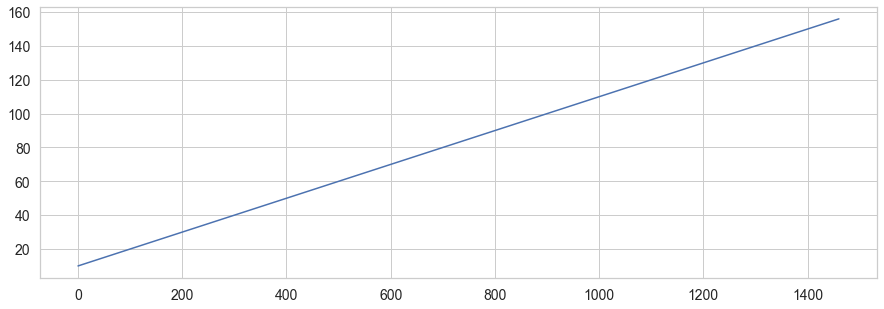

In [2]:
def gen_trend(time, slope=0):
    return slope * time

offset = 10
T = np.arange(4 * 365 + 1)
series = offset + gen_trend(T, 0.1)
hp.plot_series(T, series)

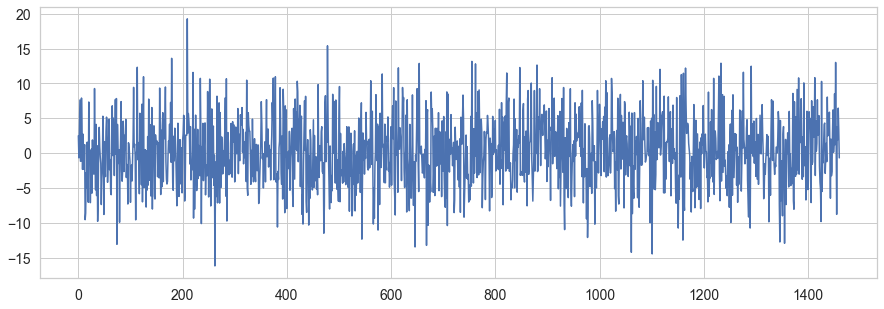

In [3]:
# Adding some Gaussian noise
def noise(time, level=5, seed=42):
    rnd = np.random.RandomState(seed)
    return rnd.randn(len(time)) * level

hp.plot_series(T, noise(T))

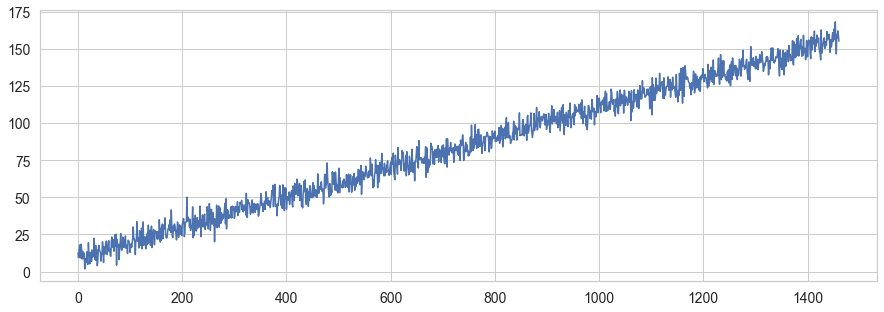

In [4]:
series += noise(T)
hp.plot_series(T, series)

- Time series can have a *seasonal components* that cause periodic fluctuations in observed data

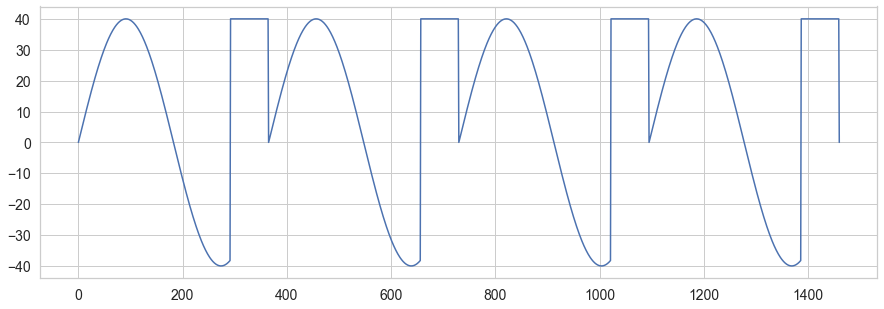

In [5]:
def seasonality(time, period, amplitude=1, phase=0):
    season_time = ((time + phase) % period) / period
    return amplitude * np.where(season_time < 0.8,
                    np.sin(season_time  * 2 *np.pi), 1)

seasons = seasonality(T, period=365, amplitude=40)
hp.plot_series(T, seasons)

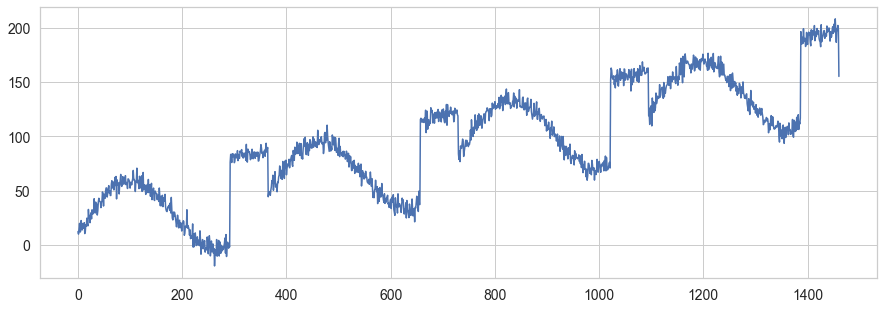

In [6]:
slope = 0.05
series += seasons
hp.plot_series(T, series)

# Recurrent Neural Networks (RNNs)

- RNNs are designed to "remember" their experience while considering the current input
  - Use loops to avoid solving the problems from scratch

## Dynamic systems

- The idea of recurrent computations corresponds to a classical dynamic system
  $$\vec{s}^{(t)} = f(\vec{s}^{(t-1)} \mid \vec{w})$$
where $\vec{s}^{t}$ is the state of the system
  - The equation is recurrent as it refers to a state of the system at the previous time 
  - Computation can be done by *unfolding* the equation, e.g., for the time points $t=3$
  $$\vec{s}^{(3)} = f(f(\vec{s}^{(1)} \mid \vec{w}) \mid \vec{w})$$

## RNNs idea

- Many RNNs can be represented using a similar equation
$$\vec{h}^{(t)} = f(\vec{h}^{(t-1)}, \vec{x}^{(t)} \mid \vec{w})$$
where $\vec{h}^{(t)}$ is a vector representing the hidden (internal) state, and $\vec{x}^{(t)}$ is an input signal
- Predictions are made by interpreting the hidden state
  - $\vec{h}^{(t)}$ summarizes the experience of the network from previously seen observations $(\vec{x}^{(t)},\vec{x}^{(t-1)},\dots,\vec{x}^{(1)})$, and can be used to predict the future
      - for instance, predict the next word given previous words
- That is, the equation can be unfolded after $t$ steps with the function $g^{(t)}$, which represents the repeated application of the function $f$
$$\begin{align}
    \vec{h}^{(t)} &= f(\vec{h}^{(t-1)}, \vec{x}^{(t)} \mid \vec{w}) = \\
        &= f( f(\vec{h}^{(t-2)}, \vec{x}^{(t-1)} \mid \vec{w}), \vec{x}^{(t)} \mid \vec{w}) = \dots \\
        &= f( f( \dots f(\vec{h}^{(0)}, \vec{x}^{(1)} \mid \vec{w}) \dots, \vec{x}^{(t-1)} \mid \vec{w}),\vec{x}^{(t)} \mid \vec{w}) = \\
        &= g^{(t)}(\vec{x}^{(t)},\vec{x}^{(t-1)},\dots,\vec{x}^{(1)} \mid \vec{w})
        \end{align}
$$
   - the learned model $f$ has always the same input size
   - it is possible to use the same transition function $f$ for all time steps 
   - $\Rightarrow$ model $f$ operates on all time steps and all sequence length

## Vanilla RNN 

- Consider an RNN that produces an output at *each time step with a recurrent connection between the hidden units*

\begin{align*}
\vec{h}^{(t)} & = \tanh\left(\vec{b}_h+\vec{h}^{(t-1)}\vec{W} + \vec{x}\vec{U}\right) \\
\vec{o}^{(t)} & = \vec{b}_o+\vec{h}^{(t)}\vec{V}
\end{align*}

- Vectors $\vec{x}$, $\vec{y}$, $\vec{h}$, and $\vec{o}$ correspond to input, target, hidden state and output vectors resp.
- The network maintains three matrices of weights: $\vec{U}$ - inputs, $\vec{W}$ - hidden state, and $\vec{V}$ - the outputs
- The cross-entropy loss $L$ compares $\hat{\vec{y}} = \mathit{softmax}(\vec{o})$ to the target $\vec{y}$
- This network can represent any Turing-computable function on a finite input
- For example, such RNN can be used for discrete output, like [character prediction](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/rnn-h-h.svg" width="60%"/>
</center>
<span class="cite">RNN diagrams from templates provided by Daniel Tosone</span>

### Input structure

- Every item in a sequence $s_j$ is a tensor $t_i$: 
    - Univariate case - scalar, like in the example above
    - Multivariate case - multiple observations are provided together
        - vector, e.g., weather observations (temperature, pressure, humidity)  
        - matrix, like an image of the sky, or a tensor, e.g., image + weather observations 

- Sequences organized in batches $b_k$
    - A batch of sequences is presented to a network
    - Update of weights is performed after each batch
    - Processing of the batch with $n$ sequences is performed by applying $n$ copies of an RNN to each element of a sequence

### One-step lookahead training

- One batch with 2 sequences of length $n$
- The goal is to predict the next element of a sequence (one-step) give the previous one
- Parallel processing of $i$-th elements of all sequences 
    - For each *batch*, the `DataLoader` outputs tensors with dimensions *(seq, elements)*, where 
        - *batch* is the number of batches that the dataset is split into by the data loader
        - *seq* is the length of a sequence
        - *elements* stands for the dimension of input, e.g., 0 (float number) in the example above, or 2 in case of an image with a single channel

\begin{align*}
\vec{h}^{(t)} & = \tanh\left(\vec{b}_h+\vec{h}^{(t-1)}\vec{W} + \vec{x}\vec{U}\right) \\
\vec{o}^{(t)} & = \vec{b}_o+\vec{h}^{(t)}\vec{V}
\end{align*}
        
- In every iteration: 
    - $\vec{x}$ and $\vec{U}$ have dimensions *(batch, elements)* and *(elements, hidden)*; their dot-product *(batch, hidden)*
    - $\vec{h}^{(t-1)}\vec{W}$ has dimensions *(batch, hidden)*
    - Note: in the first iteration *(1, hidden)* + *(batch, hidden)* = *(batch, hidden)*  using [broadcasting](https://pytorch.org/docs/stable/notes/broadcasting.html)
- Outputs can be generated in parallel from the recorded hidden states

### Training schema

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/rnn-inputs.svg" width="40%"/>
</center>

In [7]:
class RNN(torch.nn.Module):

    def __init__(self, n_input, n_hidden, n_output, device=None):
        super(RNN, self).__init__()
        self.n_hidden = n_hidden
        self.device = device
        
        self.U = nn.Linear(n_input, n_hidden)
        self.W = nn.Linear(n_hidden, n_hidden)
        self.V = nn.Linear(n_hidden, n_output)
         
    def init_hidden(self):        
        h = torch.zeros(1, self.n_hidden) + 0.01  # 0.01
        return h.to(self.device)   
        
    # expects input of the shape (seq, element)
    def forward(self, data, h):
        hs = []
        for i in range(data.shape[1]):
            x = data[:,i].reshape(-1,1)
            h = torch.tanh(self.W(h) + self.U(x))
            # store hidden states with the sequence dimension: (seq, elem_position, hidden)
            hs.append(h.unsqueeze(0)) 
            
        # concatenate hidden states and reshape 
        # (seq, batch, hidden) -> (batch, seq, hidden) -> (batch*seq, hidden)
        # make sure that the tensor is contigious (memory allocation)
        hs = torch.cat(hs, dim=0).transpose(0,1).contiguous().view(-1, self.n_hidden)
        o = self.V(hs).reshape(1,-1)
        return o, h

### Test the implementation

In [8]:
n_input, n_hidden, n_out = 1, 3, 1

X = torch.Tensor([[1,2,3,4,5], [2,3,4,5,6]])

model = RNN(n_input, n_hidden, n_out)
out, state = model(X, model.init_hidden())

print("Computed {} outputs for {} sequences in a batch\nLast state: {},\noutputs: {}".
      format(out.shape[0], X.shape[0], state, out))

Computed 1 outputs for 2 sequences in a batch
Last state: tensor([[-0.6225, -0.7355, -0.9488],
        [-0.6822, -0.8283, -0.9726]], grad_fn=<TanhBackward0>),
outputs: tensor([[0.7469, 0.8314, 0.9088, 0.9720, 1.0138, 0.8688, 0.9169, 0.9694, 1.0141,
         1.0446]], grad_fn=<ViewBackward0>)


### Gradient clipping

- Deep architectures often suffer from the *vanishing gradients* problem, when training signals cannot be transmitted from the loss function to the first layers of the network
- RNNs often also have a problem of *exploding gradients*
    - Iterative application of matrix multiplication can be numerically instable 
    - The longer is the consumed sequence, the harder can be the problem
- The problem can be avoided by ensuring that the loss function is sufficiently smooth
    - A function $\mathbb{R}^n \to \mathbb{R}$ is Lipschitz continuous if its grows is bounded by the scaled change of its argument
    $$|f(\vec{x}) - f(\vec{y})| \leq L \|\vec{x} - \vec{y}\|$$
    - Since $\vec{y} \gets \vec{x} - \eta\vec{g}$, where $\vec{g} = \nabla f(\vec{x})$ the condition above can be rewritten
    $$|f(\vec{x}) - f(\vec{x} - \eta \vec{g})| \leq L \eta \|\vec{g}\|$$
- Enforcement of Lipschitz continuoity can be done in two general ways
    - Selection of a sufficiently small learning rate $\eta$
        - Will affect *all* gradients regardless whether they are small or large
        - Scheduling of learning rate might help to mitigate this issue
    - **Gradient clipping** that sets the selected parameter $L$ as the upper bound
    $$\text{if } \| \vec{g} \| > L \text{ then }  \vec{g} \gets \frac{\vec{g}L}{\| \vec{g} \|}$$ 



### Train the model

In [9]:
def train(model, data, device, opt, crit, clip=5, epochs=1):
    model.train()
    for i in range(epochs):
        h = model.init_hidden()        
        for X, y in data:
            X, y = X.to(device), y.to(device)
            model.zero_grad()
            out,_ = model(X, h)
            loss = crit(out, y.reshape(1,-1))
            loss.backward()
            if clip != 0:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
        
        if epochs < 10 or i%(epochs//10) == 0 or i == epochs-1:
            print("Epoch {} - loss: {:.3f}:".format(i, loss.item()))
    return model

In [10]:

n_input, n_hidden, n_out = 1, 10, 1

device = torch.device("cpu")
rnn = RNN(n_input, n_hidden, n_out, device).to(device)
opt = torch.optim.Adam(rnn.parameters(), lr=0.1)
crit = nn.MSELoss()

X = torch.Tensor([[1,2,3,4,5], [2,3,4,5,6]])
y = torch.Tensor([[2,3,4,5,6], [3,4,5,6,7]]).float()
data = DataLoader(TensorDataset(X,y), batch_size=2)

model = train(rnn, data, device, opt, crit, clip=10, epochs=300)

Epoch 0 - loss: 17.047:
Epoch 30 - loss: 0.233:
Epoch 60 - loss: 0.013:
Epoch 90 - loss: 0.000:
Epoch 120 - loss: 0.000:
Epoch 150 - loss: 0.000:
Epoch 180 - loss: 0.000:
Epoch 210 - loss: 0.000:
Epoch 240 - loss: 0.000:
Epoch 270 - loss: 0.000:
Epoch 299 - loss: 0.000:


### Applications

In [11]:
def predict(model, data, h=None):
    if h is None:
        h = model.init_hidden()
    model.eval()
    with torch.no_grad():
        out, h = model(data, h)
    return out, h

def sample(model, data, sample_size=100):
    h = model.init_hidden()
    sample = []
    with torch.no_grad():
        for i in range(sample_size):
            data, h = predict(model, data, h)
            sample += data[:,-1].tolist()
    return sample

ex = torch.Tensor([[3]])
out, h = predict(model, ex)
print("Input sequence: ", ex, "\nPredictions: ", out)

print("Generate 10 elements: ", ["%.5f" % i for i in sample(model, ex, 10)])

Input sequence:  tensor([[3.]]) 
Predictions:  tensor([[4.1456]])
Generate 10 elements:  ['4.14562', '4.20601', '5.06286', '6.02755', '7.00398', '7.03402', '7.03410', '7.03410', '7.03410', '7.03410']


## Time series analysis with RNN

#### Create a dataset

- The original sequence is used to generate subsequences of a predefined length
    - Given a sequence: $(1,2,3,4,5,6)$ and the length $3$, then
        - $s_1:\; (1,2,3)$ with the target $4$,
        - $s_2:\; (2,3,4)$ with the target $5$, and
        - $s_3:\; (3,4,5)$ with the target $6$
- The sequences are stored in a dataset that organize them in batches:
    - If the batch size is 2 then 
        - $b_1: \; (s_1,s_2)$, and 
        - $b_2: \; (s_3)$

In [12]:
scaler = StandardScaler()
t_series = scaler.fit_transform(series.reshape(-1, 1))

def create_seq(data, s_len):
    xs = []
    ys = []
    for i in range(len(data)-s_len-1):
        x = data[i  : i+s_len]
        y = data[i+1: i+s_len+1]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

def plot_list(out, t_series):
    plt.figure(figsize=(15, 5))
    plt.plot(range(len(out)), out, '-', label="predicted")
    plt.plot(range(len(out)), t_series, '--', label="original")
    plt.legend()
    plt.show()

def get_loader(series, s_len, batch_size, show=False):
    X_t, y_t = create_seq(series, s_len)

    if show:
        plt.figure(figsize=(15, 5))
        plt.plot(T[0:s_len], X_t[1], '-')
        plt.plot(T[1:s_len+1], X_t[2], '--')
        plt.show()
        print("X_t shape {}, seq 1: {}".format(X_t.shape, np.around(X_t[1].T,2)))
        print("y_t shape {}, seq 1: {}".format(y_t.shape, np.around(y_t[1].T,2)))
    
    X_ds = TensorDataset(torch.from_numpy(X_t).float(), torch.from_numpy(y_t).float())
    return DataLoader(X_ds, batch_size=batch_size)

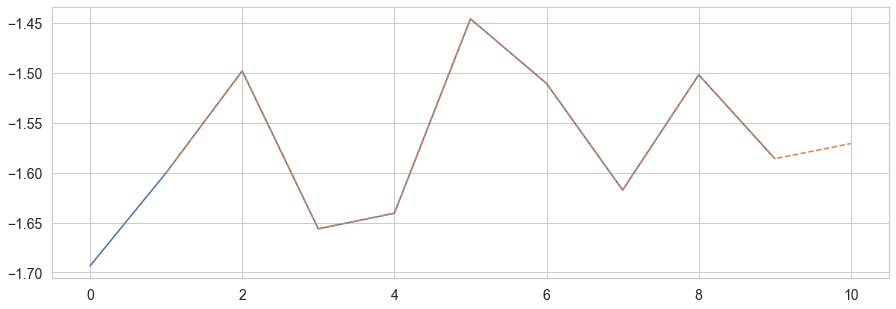

X_t shape (1450, 10, 1), seq 1: [[-1.69 -1.6  -1.5  -1.66 -1.64 -1.45 -1.51 -1.62 -1.5  -1.59]]
y_t shape (1450, 10, 1), seq 1: [[-1.6  -1.5  -1.66 -1.64 -1.45 -1.51 -1.62 -1.5  -1.59 -1.57]]


torch.Size([200, 10, 1])

In [13]:
train_loader = get_loader(t_series, s_len=10, batch_size=200, show=True)
b_id, (seq, target) = next(enumerate(train_loader))
seq.shape

### Train a model

In [14]:
n_input, n_hidden, n_out = 1, 5, 1
device = torch.device("cpu")

rnn = RNN(n_input, n_hidden, n_out).to(device)
opt = torch.optim.Adam(rnn.parameters(), lr=0.01)
crit = nn.MSELoss()
                  
rnn = train(rnn, train_loader, device, opt, crit, clip=10, epochs=10);

Epoch 0 - loss: 3.273:
Epoch 1 - loss: 1.945:
Epoch 2 - loss: 1.120:
Epoch 3 - loss: 0.636:
Epoch 4 - loss: 0.387:
Epoch 5 - loss: 0.275:
Epoch 6 - loss: 0.229:
Epoch 7 - loss: 0.208:
Epoch 8 - loss: 0.186:
Epoch 9 - loss: 0.156:


## RNN variants: teacher forcing

- RNN produces an output at each time step with a recurrent connection between the *output and hidden units*

\begin{align*}
\vec{h}^{(t)} & = \mathit{tanh}\left(\vec{b}_h+ \vec{o}^{(t-1)}\vec{W} + \vec{x}\vec{U}\right) \\
\vec{o}^{(t)} & = \vec{b}_o+\vec{h}^{(t)}\vec{V}
\end{align*}

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/rnn-h-o.svg" width="60%"/>
</center>

- Such RNN is less powerful than the previous variant since the $\vec{o^{(\cdot)}}$ must provide both, the output and the information for the next hidden state
    - Cannot simulate a Turing machine 
- However, it is easier to train because each time step can be trained independently and in parallel - *teacher forcing*
  - Is derived from the maximum likelihood principle, e.g., for the time step $t=2$ maximize the conditional probability of $\vec{y}^{(2)}$ given both the $\vec{x}$ sequence up to $t$ and the previous target value $\vec{y}^{(1)}$ (chain rule + logarithm): 
  
  
$$
\log p \left(\vec{y}^{(1)}, \vec{y}^{(2)} \mid \vec{x}^{(1)}, \vec{x}^{(2)}\right) 
= \log p \left(\vec{y}^{(2)} \mid \vec{y}^{(1)}, \vec{x}^{(1)}, \vec{x}^{(2)}\right) + \log p \left(\vec{y}^{(1)} \mid \vec{x}^{(1)}, \vec{x}^{(2)}\right)
$$

- This type of the training is problematic for the *open-loop mode*:
  - E.g., RNNs generating text often use their latest output as input
  - The inputs seen during training can be different form the ones during the application

### RNN variations, cond.

- RNN produces an output only at *the last time step* with a recurrent connection between the *hidden units*

\begin{align*}
L\left(\{\vec{x}^{(1)},\cdots, \vec{x}^{(\tau)}\}, \{\vec{y}^{(1)},\cdots, \vec{y}^{(\tau)}\}\right) & = \sum_t L^{(t)} \\
&= - \sum_t \log p_\mathit{model} \left(\vec{y}^{(t)} \mid \{\vec{x}^{(1)},\cdots, \vec{x}^{(t)}\}\right)
\end{align*}

- $\log p_\mathit{model} \left(\vec{y}^{(t)} \mid \{\vec{x}^{(1)},\cdots, \vec{x}^{(t)}\}\right)$ is given by reading the value $y^{(t)}$ from the vector $\vec{y}^{(t)}$ 

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/rnn-h-h-long.svg" width="40%"/>
</center>

- Computation of gradient for such RNN is quite expensive: first a forward pass is done on the unrolled graph (below), and then a backward pass in the other direction - *Back-Propagation Through Time* (BPTT) 
- No parallelization is possible due to sequential operations

## Bidirectional RNNs

- RNNs considered so far capture in $\vec{h}$ only the information from the past inputs $\vec{x}^{(1)}, \cdots, \vec{x}^{(t-1)}$ and the present one $\vec{x}^{(t)}$
- In some cases, like speech recognition or NLP, the output at the current time points may depend not only on the past and current, but also some next observations
- *Bidirectional RNNs* were invented to address this issue by combining two RNNs: 
  - one moving from the beginning of a sequence and another from the end

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/Bidir-RNN.svg" width="60%"/>
</center>

- Can easily be extended to multi-dimensional inputs by having multiple RNNs going in all possible directions
  - Forward propagation equations may be written in a form showing that they use *convolutions* to compute the bottom-up input to each layer

# RNN issues: challenge of long-term dependencies

- RNN - short term memory - tend to forget examples seen along ago (appr. 20 time units in a time series)
    - Vanishing gradient, see <a href="https://distill.pub/2019/memorization-in-rnns/">a visualization</a>
    - Explosion of gradients happens only rarely, but makes optimization impossible
    - Multiple modifications to RNN were suggested over time, but there are no significant difference to the vanilla RNNs in the large studies, see <a href="https://arxiv.org/abs/1503.04069">Greff at al. [2016]</a>
    

- The main reason is that RNNs are a composition of the same function over multiple time steps
$$\vec{h}^{(t)} = \vec{W}^\top \vec{h}^{(t-1)} = (\vec{W}^t)^\top \vec{h}^{(0)}$$
$$\text{Since } \vec{W}=\vec{Q}\vec{\Lambda}\vec{Q}^\top \;\Rightarrow\; \vec{h}^{(t)} = \vec{Q}^\top\vec{\Lambda}^t\vec{Q} \vec{h}^{(0)}  $$
  - Rising eigenvalues $\vec{\Lambda}$ to the power of $t$ might make them very small - vanishing gradient, or very large - exploding 
- $\Rightarrow$ highly non-linear behavior 
    - many alternations between increasing and decreasing, 
    - different rate of change along dimensions: large number of small components in the gradient vector, and some components can be very large

# Gated RNNs

- This type of RNNs are based on the idea of creating paths through time that prevent gradients from vanishing or exploding
- Gated RNNs maintain connection weights that may change at each time step
  - $\Rightarrow$ Learn how to control changes of the weights over time
  - Introduce self-loops where a gradient can be maintained (amplified or decreased) for long periods of time

## Long Short-Term Memory (LSTM)

- Vanilla LSTM cell gets 3 inputs and provides 3 outputs
- Includes four gates (all definitions are taken from [pytorch](https://pytorch.org/docs/stable/nn.html?highlight=lstm#torch.nn.LSTM): forget gate, external input gate, as well as cell, and output gates

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/LSTM.svg" width="60%"/>
</center>

### Forget gate 

- This gate is a sigmoid unit that controls the self-loop weight to stay in the interval $[0,1]$

    $$\vec{f}^{(t)} = \sigma( \vec{W}_{xf} \vec{x}^{(t)} + \vec{W}_{hf} \vec{h}^{(t-1)} + \vec{b}_f)$$
    
    where $\vec{x}^{(t)}$ is the current input vector $\vec{h}^{(t-1)}$ is the hidden state from the previous time step, and $\vec{b}_f$ is a bias vector comprising biases for input and hidden state
    - As the name suggest this gate controls forgetting of useless information in the hidden state over time
    - Since the sigmoid range is $[0,1]$, this gate determines the "percentage" of long-term memory that can be forgotten given a input value and the hidden state representing short-term memory
    - All sigmoids in an LSTM cell have the same purpose 

### Updating the long-term memory

- Next, similarly to the forget gate, we have to decide which information from the current input must be memorized in the cell state for future decisions
- There are two gates that control this process:
  - *Cell gate* is a $\tanh$-unit that computes a vector of new candidate values that must be added to the cell state
  
   $$\vec{g}^{(t)} = \tanh(\vec{W}_{xg} \vec{x}^{(t)} + \vec{W}_{hg} \vec{h}^{(t-1)} + \vec{b}_g)$$

  - *Input gate* determines the "memorization" rate for the vector of the cell gate

    $$\vec{i}^{(t)} = \sigma( \vec{W}_{xi} \vec{x}^{(t)} + \vec{W}_{hi} \vec{h}^{(t-1)} + \vec{b}_i)$$
    
- The update of the *cell vector* is done as follows:

    $$\vec{c}^{(t)} = \vec{f}^{(t)} \otimes \vec{c}^{(t-1)} + \vec{i}^{(t)} \otimes \vec{g}^{(t)}$$
    
    where $\otimes$ denotes element-wise multiplication of matrices of the same shape (Hadamard product)

### Updating the short-term memory

- *Output gate* is based on the input to the cell and the hidden state from the previous time point 

    $$ \vec{o}^{(t)} = \sigma( \vec{W}_{xo} \vec{x}^{(t)} + \vec{W}_{ho} \vec{h}^{(t-1)} + \vec{b}_o)$$

- Corrected output vector, takes the context into account

    $$\vec{h}^{(t)} = \vec{o}^{(t)} \otimes \tanh(\vec{c}^{(t)})$$
    
    where $\tanh(\vec{c}^{(t)})$ pushes the values in the interval $[−1,1]$ to limit the influence of the long-term memory

- Practical applications show that LSTM networks can learn long-term dependencies easier than simple RNNs
- There are many variants of LSTMs, e.g., with "peepholes" which channel the state of a cell at previous time points to forget, input, and output gates 

In [15]:
class LSTM(torch.nn.Module):

    def __init__(self, n_inputs, batch_size, n_hidden=32, n_layers=2):
        super(LSTM, self).__init__()
        self.n_hidden = n_hidden
        self.n_layers = n_layers
        self.batch_size = batch_size
        #  batch_first = True -> input and output tensors are provided as (batch, seq, feature)
        self.lstm = torch.nn.LSTM(n_input, n_hidden, n_layers, batch_first=True)        
        self.fc = torch.nn.Linear(n_hidden, 1)
    
    def init_hidden(self, batch_size):
        # initialize h and c (two tensors in a tuple)
        h = (torch.zeros(self.n_layers, batch_size, self.n_hidden),
                  torch.zeros(self.n_layers, batch_size, self.n_hidden))
        return h
       
    def forward(self, s, h):
        # batches can be of different length, e.g. the last one
        # s shape (batch_size, s_len, features)
        s, h = self.lstm(s, h)
        # reshape s from (batch_size, s_len, n_hidden) 
        # to (batch_size * s_len, n_hidden)
        s = self.fc(s.contiguous().view(-1, self.n_hidden))
        return s, h

In [16]:
def train(model, train_loader, opt, crit, scheduler, clip=10, epochs = 100):
    model.train()
    for epoch in range(epochs):
        for X, y in train_loader:
            h = model.init_hidden(X.shape[0])
            model.zero_grad()
            pred, _ = model(X, h)
            loss = crit(pred, y.reshape(-1,1))
            loss.backward()
            if clip != 0:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
        scheduler.step()
        if epoch %  (epochs // 10) == 0:
            print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

### Model training

In [17]:
device = torch.device("cpu")
n_input, n_hidden, n_out, s_len, batch_size = 1, 64, 1, 20, 200
train_loader = get_loader(t_series, s_len, batch_size)

model = LSTM(n_input, batch_size, n_hidden, n_layers=2)
crit = torch.nn.MSELoss(reduction="sum")
opt = torch.optim.Adam(model.parameters(), lr=0.1)
scheduler = StepLR(opt, step_size=20, gamma=0.7)

train(model, train_loader, opt, crit, scheduler, epochs=200)

Epoch: 0, loss: 158.16867
Epoch: 20, loss: 1019.95087
Epoch: 40, loss: 8.57421
Epoch: 60, loss: 14.36803
Epoch: 80, loss: 12.15509
Epoch: 100, loss: 9.99890
Epoch: 120, loss: 15.38926
Epoch: 140, loss: 13.32875
Epoch: 160, loss: 7.54910
Epoch: 180, loss: 7.72645


### One-step prediction

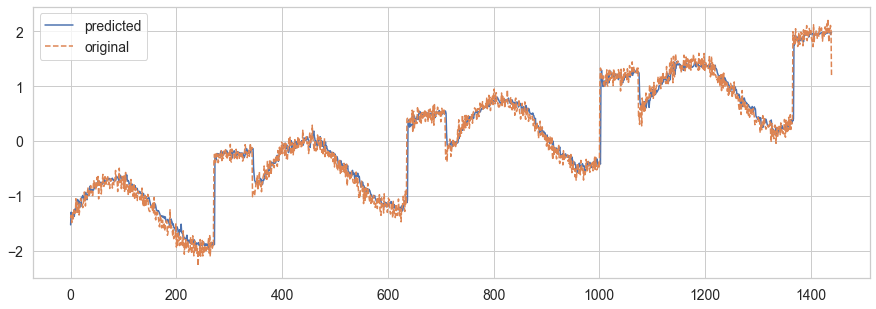

In [18]:
model.eval()

out = []
with torch.no_grad():
    for X, _ in train_loader:
        h = model.init_hidden(X.shape[0])
        o, h = model(X, h)
        out += torch.flatten(o.reshape(X.shape[0],-1,1)[:,-1,:]).tolist()

plot_list(out, t_series[s_len+1:])

### Generation

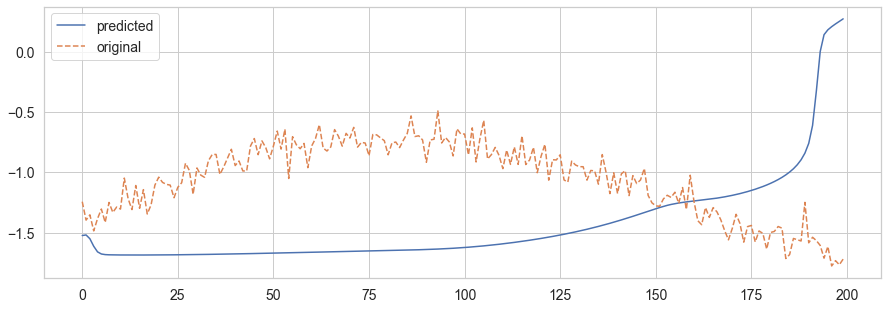

In [19]:
out, n_samples = [], 200 
model.eval()
with torch.no_grad():
    X, _ = next(iter(train_loader))
    # create a batch from the first (0) sequence of the time series
    X = X[0].unsqueeze(0)
    h = model.init_hidden(X.shape[0])
    for i in range(n_samples):
        X, h = model(X, h)
        out += X[-1].tolist()
        X = X.unsqueeze(0)

plot_list(out, t_series[s_len:n_samples + s_len])

## Gated Recurrent Unit (GRU) 

- The most well-known spin-off of the LSTM cell is a GRU
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/GRU.svg" width="60%"/>
</center>

### GRU gates

- The main idea is to simplify computations by 
  - combining forget and input gates into a single *update gate*
  
  $$\vec{z}^{(t)} = \sigma( \vec{W}_{xz}\vec{x}^{(t)} + \vec{W}_{hz}\vec{h}^{(t-1)} + \vec{b}_z ) $$
  
  - merging the computation of cell and the hidden states in the *reset gate*
  
  $$\vec{r}^{(t)} = \sigma( \vec{W}_{xr}\vec{x}^{(t)} + \vec{W}_{hr}\vec{h}^{(t-1)} + \vec{b}_r )$$
  
  - control memorization of new information by the *new gate*

  $$\vec{n}^{(t)} = \tanh( \vec{W}_{xn}\vec{x}^{(t)} + \vec{b}_{xn} + \vec{r}^{(t)} \otimes (\vec{W}_{hr}\vec{h}^{(t-1)} + \vec{b}_{hn}) )$$

- The updated hidden state is computed as

  $$\vec{h}^{(t)} =  (1 - \vec{z}^{(t)}) \otimes \vec{n}^{(t)} + \vec{z}^{(t)} \otimes \vec{h}^{(t-1)}$$